Predictive Analytics for Urban Transit: A Multi-Model Approach

In [1]:
# ============================================================
# 1️⃣ IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

from xgboost import XGBRegressor, XGBClassifier

from sklearn.metrics import (
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

np.random.seed(42)
sns.set_style("whitegrid")

SYNTHETIC DATA GENERATION

In [2]:
n = 3000

data = pd.DataFrame()

# Features
data["Distance_to_Stop"] = np.random.uniform(0.5, 15.0, n)
data["Traffic_Density"] = np.random.beta(2, 2, n)   # balanced distribution
data["Weather_Condition"] = np.random.choice([0,1], n, p=[0.7,0.3])
data["Hour_of_Day"] = np.random.randint(0,24,n)
data["Day_of_Week"] = np.random.randint(0,7,n)

# Peak hour
data["Is_Peak_Hour"] = data["Hour_of_Day"].apply(
    lambda x: 1 if (8<=x<=10) or (17<=x<=19) else 0
)

# Weekend indicator
data["Is_Weekend"] = data["Day_of_Week"].apply(lambda x: 1 if x>=5 else 0)

# -------- REALISTIC DELAY FORMULA --------

base_delay = 2

distance_effect = 0.8 * data["Distance_to_Stop"]

traffic_effect = 12 * (data["Traffic_Density"]**2)

weather_effect = 4 * data["Weather_Condition"]

peak_effect = 5 * data["Is_Peak_Hour"]

interaction_effect = (
    15 * data["Traffic_Density"] * data["Is_Peak_Hour"] +
    8 * data["Weather_Condition"] * data["Traffic_Density"]
)

weekend_reduction = -3 * data["Is_Weekend"]

noise = np.random.normal(0, 2, n)

data["Actual_Delay_Mins"] = (
    base_delay +
    distance_effect +
    traffic_effect +
    weather_effect +
    peak_effect +
    interaction_effect +
    weekend_reduction +
    noise
)

data["Actual_Delay_Mins"] = data["Actual_Delay_Mins"].clip(lower=0)

# Classification label
data["Is_Delayed"] = data["Actual_Delay_Mins"].apply(lambda x: 1 if x > 5 else 0)

data.head()

,Distance_to_Stop,Traffic_Density,Weather_Condition,Hour_of_Day,Day_of_Week,Is_Peak_Hour,Is_Weekend,Actual_Delay_Mins,Is_Delayed
0,5.930832,0.570096,0,8,4,1,0,23.219667,1
1,14.285357,0.650431,0,3,6,0,1,14.934991,1
2,11.113912,0.398991,1,22,1,0,0,15.996154,1
3,9.180548,0.589543,0,23,6,0,1,8.778366,1
4,2.762270,0.177590,0,9,6,1,1,11.601506,1


TRAIN-TEST SPLIT

In [3]:
features = [
    "Distance_to_Stop",
    "Traffic_Density",
    "Weather_Condition",
    "Hour_of_Day",
    "Is_Peak_Hour",
    "Day_of_Week",
    "Is_Weekend"
]

X = data[features]
y_reg = data["Actual_Delay_Mins"]
y_class = data["Is_Delayed"]

X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

_, _, y_train_class, y_test_class = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

MODEL DEFINITIONS

In [4]:
# Regression Models
reg_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=6),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        random_state=42
    )
}

# Classification Models
class_models = {
    "Linear Regression (Thresholded)": LinearRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=6),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss"
    )
}

REGRESSION METRICS

In [5]:
reg_results = {}

for name, model in reg_models.items():
    model.fit(X_train, y_train_reg)
    preds = model.predict(X_test)

    mse = mean_squared_error(y_test_reg, preds)
    rmse = np.sqrt(mse)

    reg_results[name] = {"MSE": mse, "RMSE": rmse}

reg_results_df = pd.DataFrame(reg_results).T
reg_results_df

,MSE,RMSE
Linear Regression,6.928859,2.632273
Decision Tree,8.605132,2.933450
XGBoost,4.708865,2.169992


CLASSIFICATION METRICS

In [6]:
class_results = {}

for name, model in class_models.items():

    if name == "Linear Regression (Thresholded)":
        model.fit(X_train, y_train_reg)
        preds = model.predict(X_test)
        preds = (preds > 5).astype(int)
    else:
        model.fit(X_train, y_train_class)
        preds = model.predict(X_test)

    acc = accuracy_score(y_test_class, preds)
    prec = precision_score(y_test_class, preds)
    rec = recall_score(y_test_class, preds)
    f1 = f1_score(y_test_class, preds)

    class_results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    }

class_results_df = pd.DataFrame(class_results).T
class_results_df

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:26:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Accuracy,Precision,Recall,F1-Score
Linear Regression (Thresholded),0.940000,0.967450,0.967450,0.967450
Decision Tree,0.930000,0.958707,0.965642,0.962162
XGBoost,0.948333,0.959507,0.985533,0.972346


VISUALIZATIONS

Regression MSE Comparison

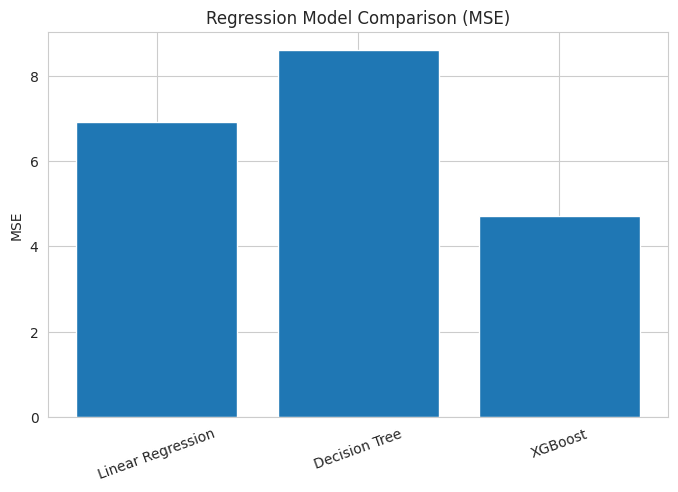

In [7]:
plt.figure(figsize=(8,5))
plt.bar(reg_results_df.index, reg_results_df["MSE"])
plt.title("Regression Model Comparison (MSE)")
plt.ylabel("MSE")
plt.xticks(rotation=20)
plt.show()

Classification Accuracy Comparison

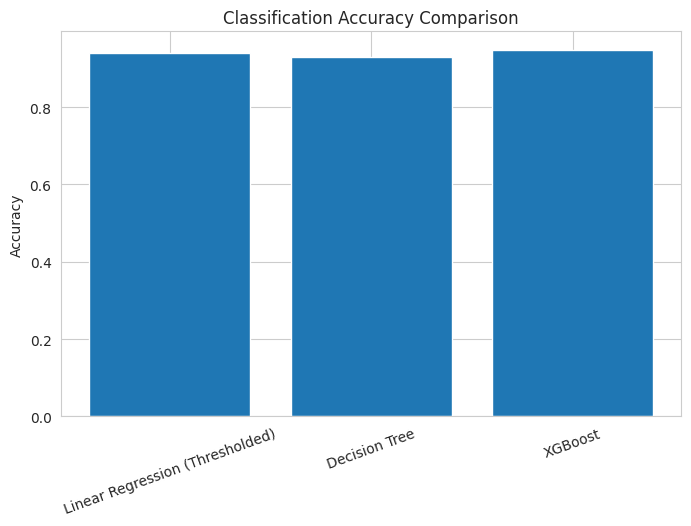

In [8]:
plt.figure(figsize=(8,5))
plt.bar(class_results_df.index, class_results_df["Accuracy"])
plt.title("Classification Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

Confusion Matrix (Best Model – XGBoost)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:26:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


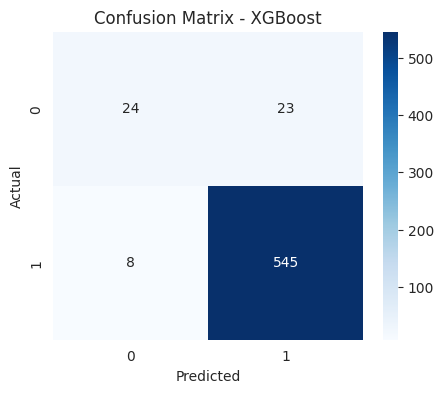

In [9]:
best_model = class_models["XGBoost"]
best_model.fit(X_train, y_train_class)
preds = best_model.predict(X_test)

cm = confusion_matrix(y_test_class, preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Actual vs Predicted (Regression – XGBoost)

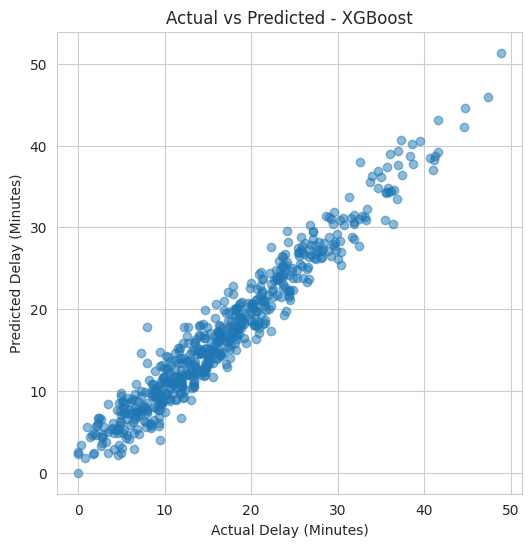

In [10]:
best_reg = reg_models["XGBoost"]
best_reg.fit(X_train, y_train_reg)
preds = best_reg.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, preds, alpha=0.5)
plt.xlabel("Actual Delay (Minutes)")
plt.ylabel("Predicted Delay (Minutes)")
plt.title("Actual vs Predicted - XGBoost")
plt.show()

ROC Curve

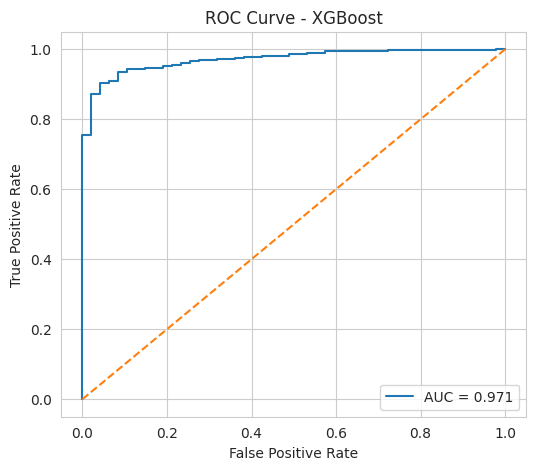

In [11]:
y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test_class, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

FEATURE CORRELATION HEATMAP

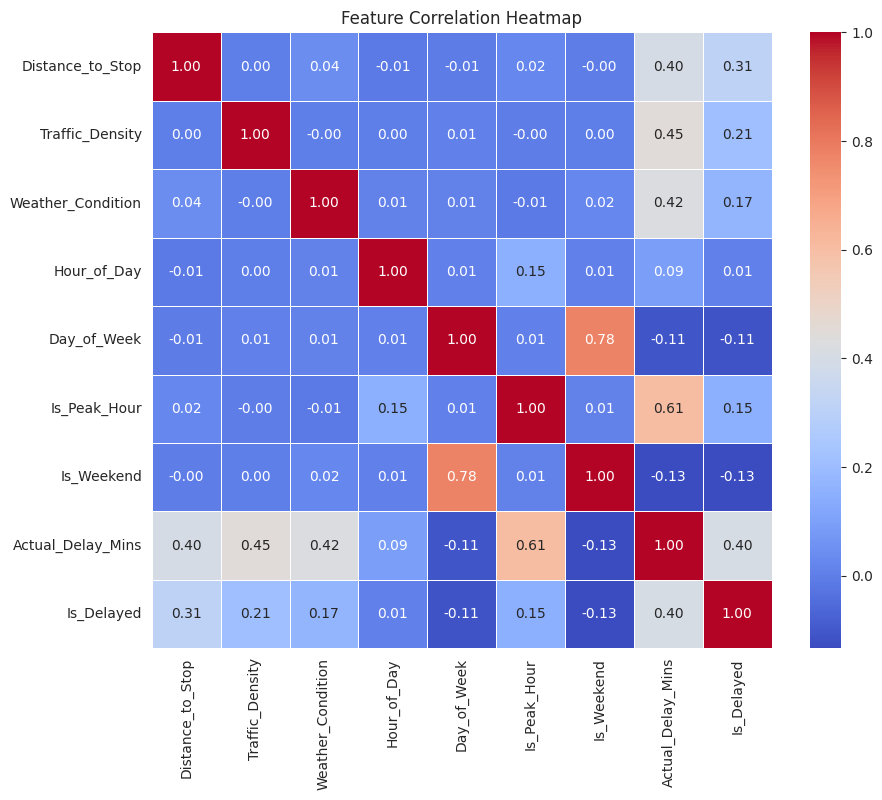

In [12]:
# ============================================================
# FEATURE CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(10,8))

correlation_matrix = data.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

Combined Regression Comparison (MSE + RMSE)

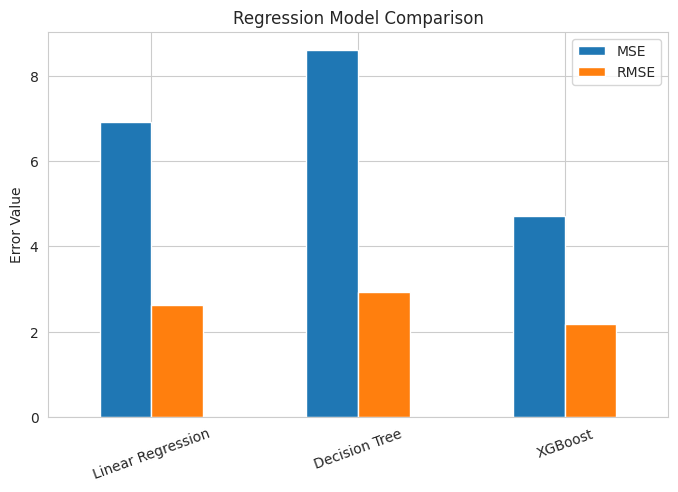

In [13]:
# ============================================================
# REGRESSION MODEL COMPARISON
# ============================================================

reg_results_df.plot(kind="bar", figsize=(8,5))

plt.title("Regression Model Comparison")
plt.ylabel("Error Value")
plt.xticks(rotation=20)
plt.show()

Combined Classification Comparison (All Metrics)

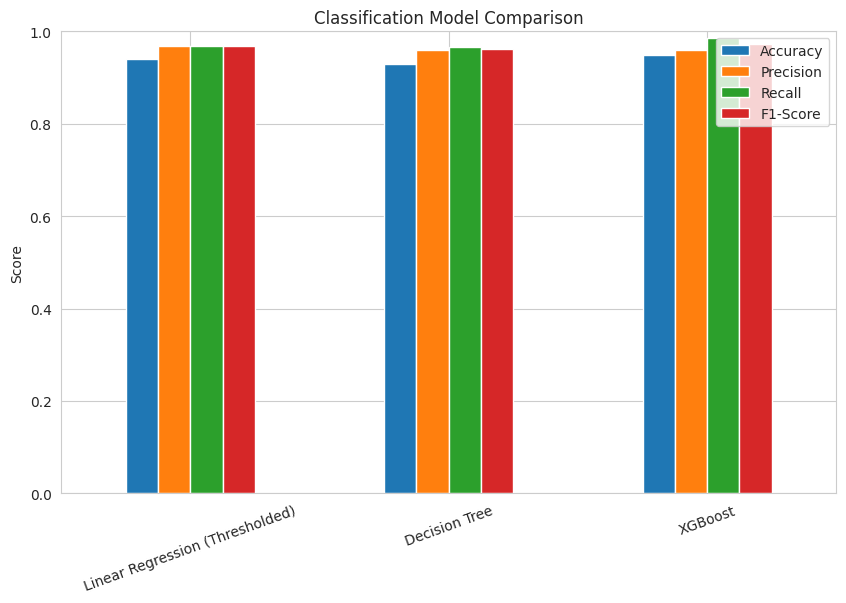

In [14]:
# ============================================================
# CLASSIFICATION MODEL COMPARISON
# ============================================================

class_results_df.plot(kind="bar", figsize=(10,6))

plt.title("Classification Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0,1)
plt.show()

In [18]:
# Make model names consistent
class_results_df = class_results_df.rename(
    index={"Linear Regression (Thresholded)": "Linear Regression"}
)

MODEL COMPARISON

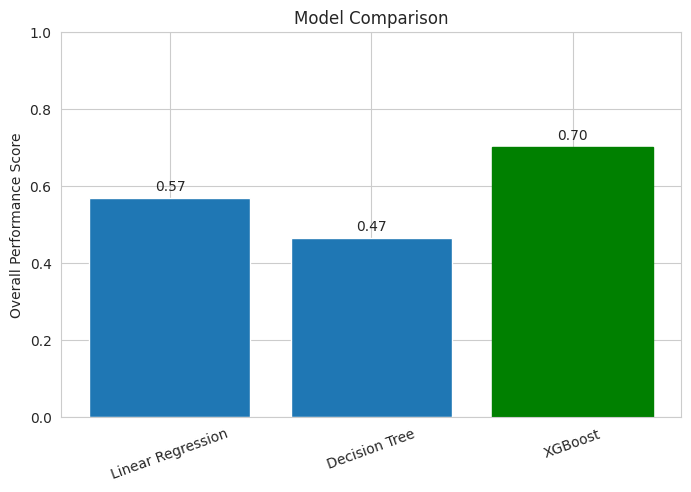

In [19]:
# ============================================================
# FINAL MODEL COMPARISON GRAPH
# ============================================================

# Normalize MSE (lower is better)
max_mse = reg_results_df["MSE"].max()
reg_score = 1 - (reg_results_df["MSE"] / max_mse)

# Classification accuracy
class_score = class_results_df["Accuracy"]

# Combine both
final_score = (reg_score + class_score) / 2

plt.figure(figsize=(8,5))
bars = plt.bar(final_score.index, final_score.values)

plt.title("Model Comparison")
plt.ylabel("Overall Performance Score")
plt.xticks(rotation=20)
plt.ylim(0,1)

# Highlight best model
best_model = final_score.idxmax()
bars[list(final_score.index).index(best_model)].set_color("green")

# Add value labels
for i, v in enumerate(final_score.values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()